In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import QuantLib as ql
import rateslib as rl

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

In [29]:
cache_path = r"C:\Users\chris\clee\project-oasis\private\sdranalytics\.cache"
start = NY_tz.localize(datetime.datetime(2025, 12, 29, 7, 0))
end = NY_tz.localize(datetime.datetime(2025, 12, 29, 17, 30))

In [ ]:
from SDRUtils.products import USD_SOFR_SwapProduct

product = USD_SOFR_SwapProduct()
df = product.build_classification_dataframe(start=start, end=end, cache_path=cache_path)

df

In [10]:
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE

bcsfc = BARCHART_STIRF_CURVE()

In [11]:
ts = pytz.timezone("America/Chicago").localize(datetime.datetime(2025, 12, 31, 16, 0)) 
c, s = bcsfc.build_curve(curve_name="USD-SOFR-1D-Q12", timestamp=ts)

{'0/1/2': <rl.Fly at 0x21243a9dc10>, '1/2/3': <rl.Fly at 0x2124391a830>, '2/3/4': <rl.Fly at 0x2124391a990>, '3/4/5': <rl.Fly at 0x21243b04910>, '4/5/6': <rl.Fly at 0x21243b04af0>, '5/6/7': <rl.Fly at 0x21243abe180>, '6/7/8': <rl.Fly at 0x21243b60fd0>, '7/8/9': <rl.Fly at 0x21243b61350>, '8/9/10': <rl.Fly at 0x21243a1bbd0>, '9/10/11': <rl.Fly at 0x21243a1bf50>}
[3.519999999999996, 3.305000000000007, 3.155000000000001, 3.1099999999999994, 3.114999999999995, 3.1500000000000057, 3.200000000000003, 3.260000000000005, 3.3299999999999983, 3.394999999999996, 3.4549999999999983, 3.5049999999999955, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SUCCESS: `conv_tol` reached after 12 iterations (levenberg_marquardt), `f_val`: 2.3482281625809926e-07, `time`: 0.0367s


(<Figure size 1600x900 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x21245c75f90>])

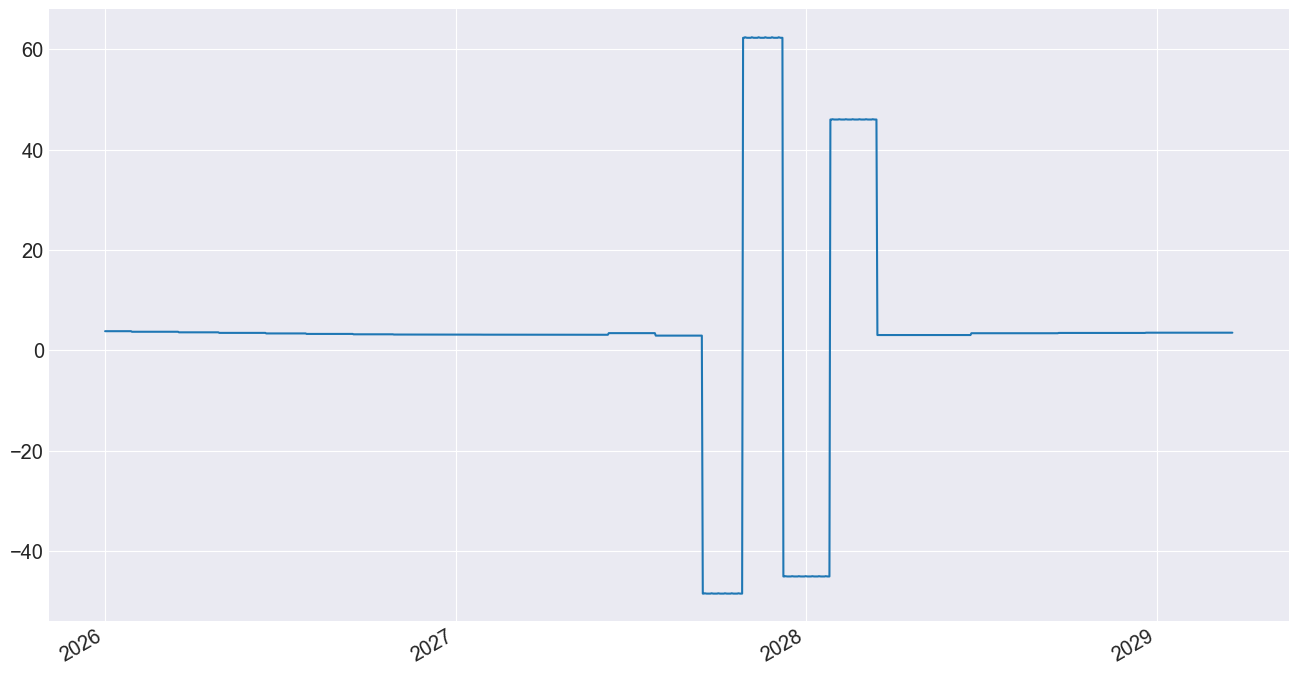

In [13]:
c.plot("1d")